In [1]:
# %% [markdown]
# # 01 — Exploratory Data Analysis (EDA)
# ## Online Retail II Dataset
# **RetailPulse — Zidio Development | March 2026**


In [2]:
# %% [markdown]
# ## Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
# %% [markdown]
# ## Load Dataset

In [5]:
df = pd.read_excel('../data/raw/online_retail_ii/online_retail_II.xlsx')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.info(show_counts=True))

Shape: (525461, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB
None


In [6]:
# %% [markdown]
# ## Data Cleaning

In [7]:
print(f"Before cleaning: {df.shape}")

# Remove cancelled
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df = df.dropna(subset=['Customer ID'])
df['Customer ID'] = df['Customer ID'].astype(int)
df['TotalAmount'] = df['Quantity'] * df['Price']
df = df.drop_duplicates()

print(f"After cleaning: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique invoices: {df['Invoice'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")

Before cleaning: (525461, 8)


After cleaning: (400916, 9)
Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Unique customers: 4,312
Unique invoices: 19,213
Unique products: 4,017
Countries: 37


In [8]:
# %%[markdown]
# ## Missing Values Matrix

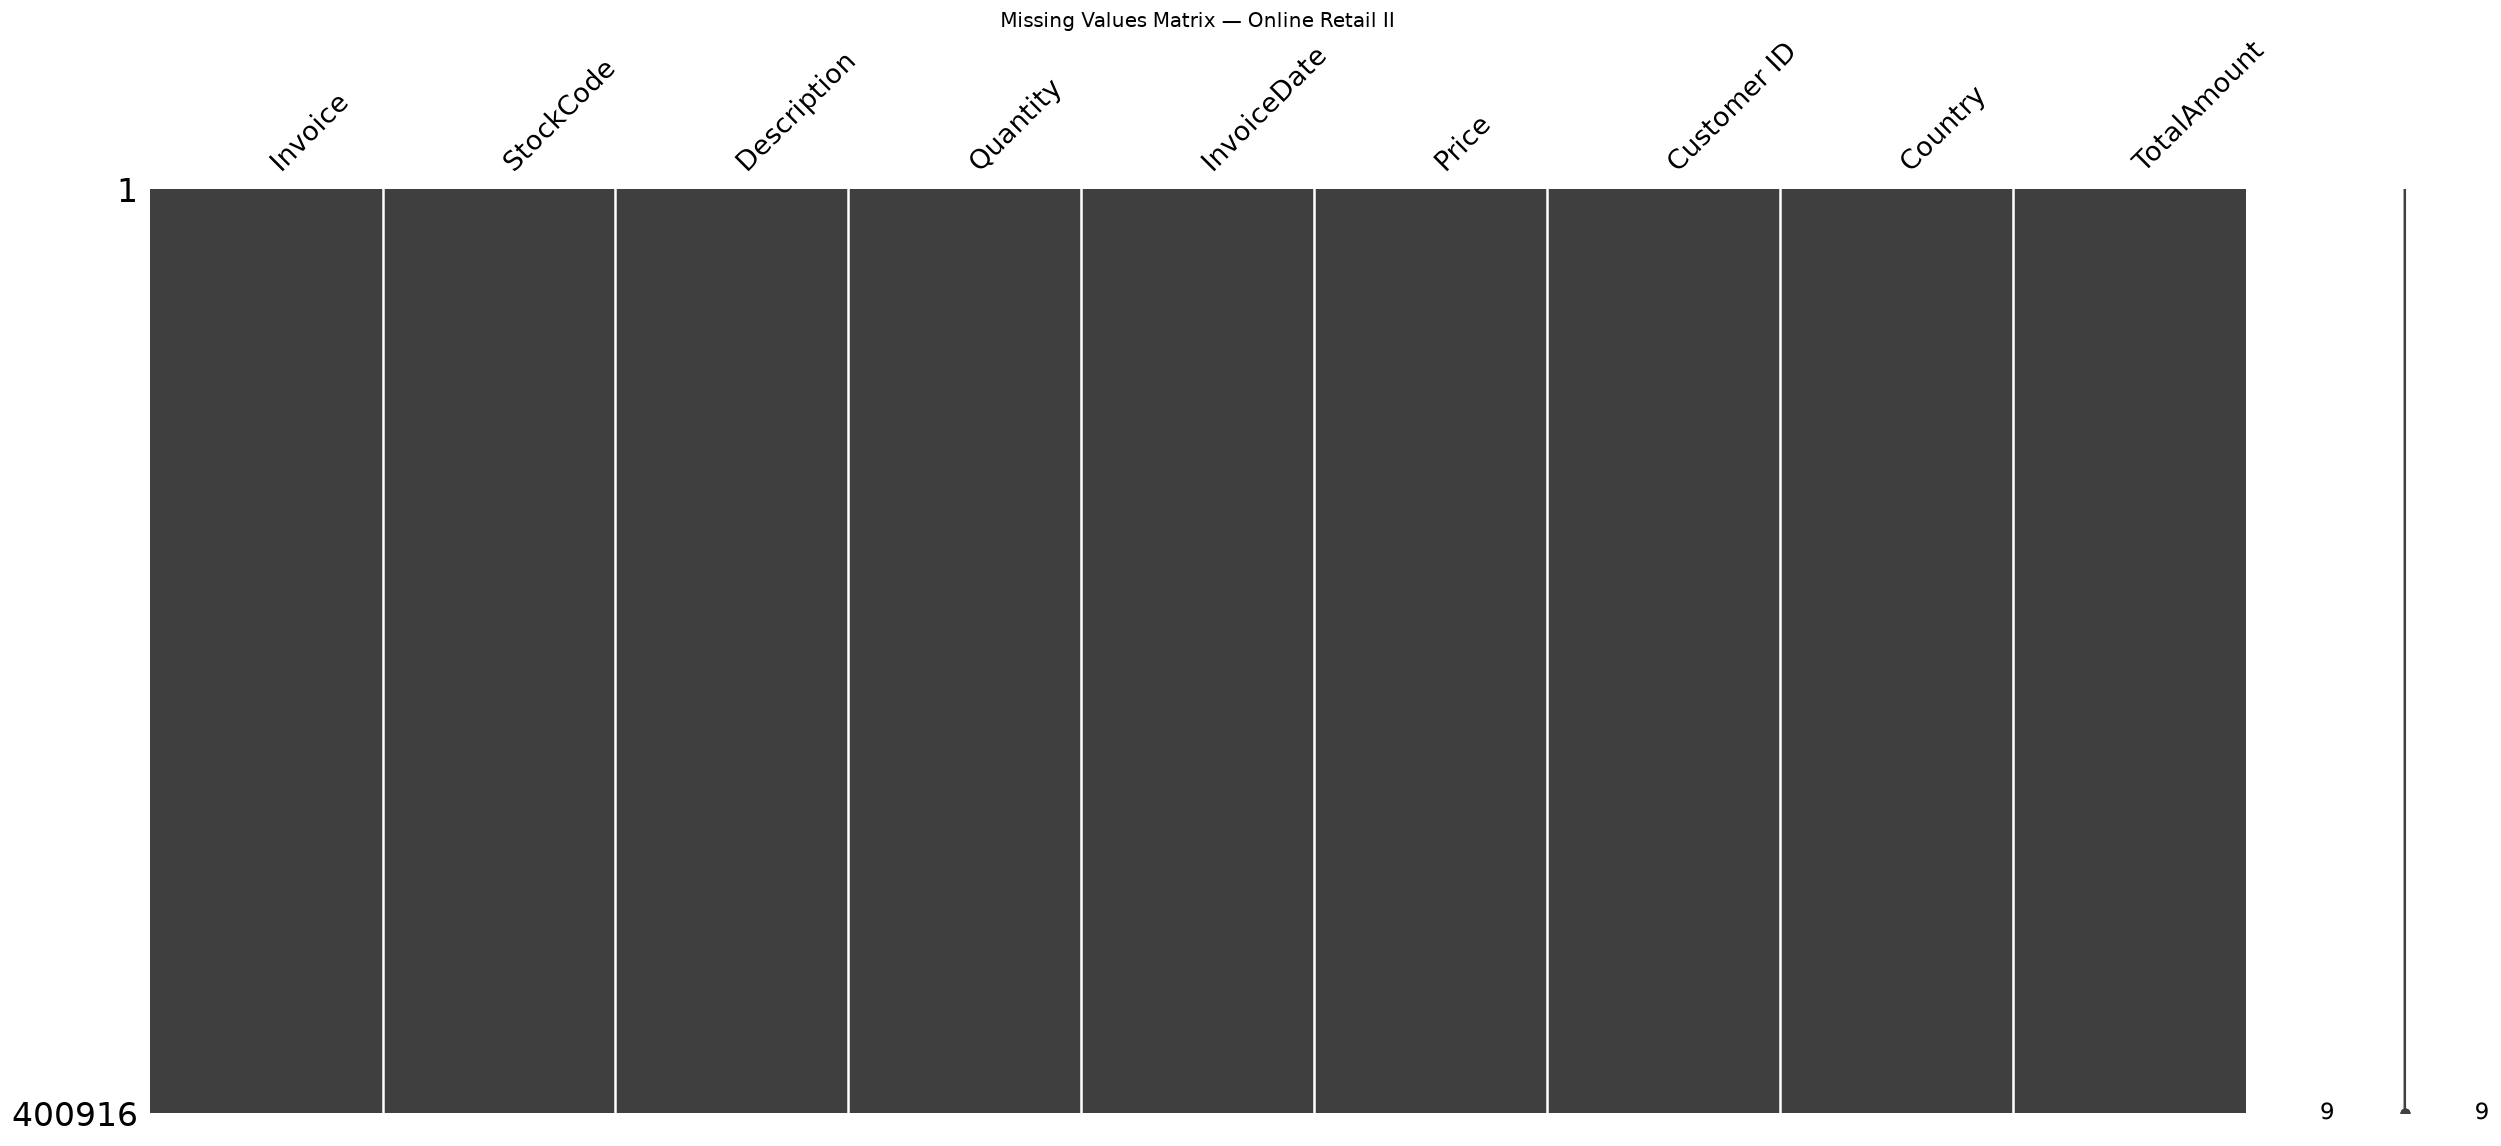

In [9]:
msno.matrix(df)
plt.title("Missing Values Matrix — Online Retail II")
plt.tight_layout()
plt.savefig('../reports/missing_values.png', bbox_inches='tight')
plt.show()

In [10]:
# %%[markdown]
# ## Distribution Analysis

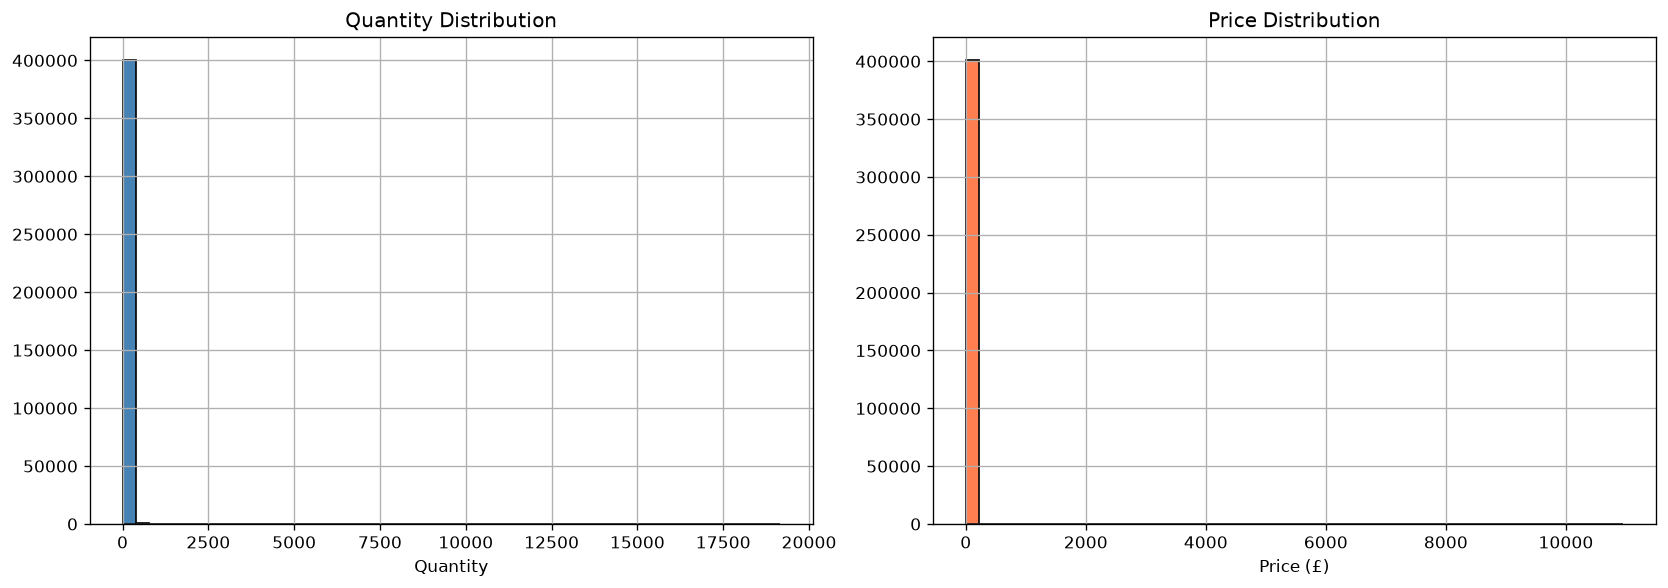

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Quantity'].hist(ax=axes[0], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Quantity Distribution')
axes[0].set_xlabel('Quantity')
df['Price'].hist(ax=axes[1], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Price Distribution')
axes[1].set_xlabel('Price (£)')
plt.tight_layout()
plt.savefig('../reports/distributions.png', bbox_inches='tight')
plt.show()

In [12]:
# %%[markdown]
# ## Correlation Heatmap

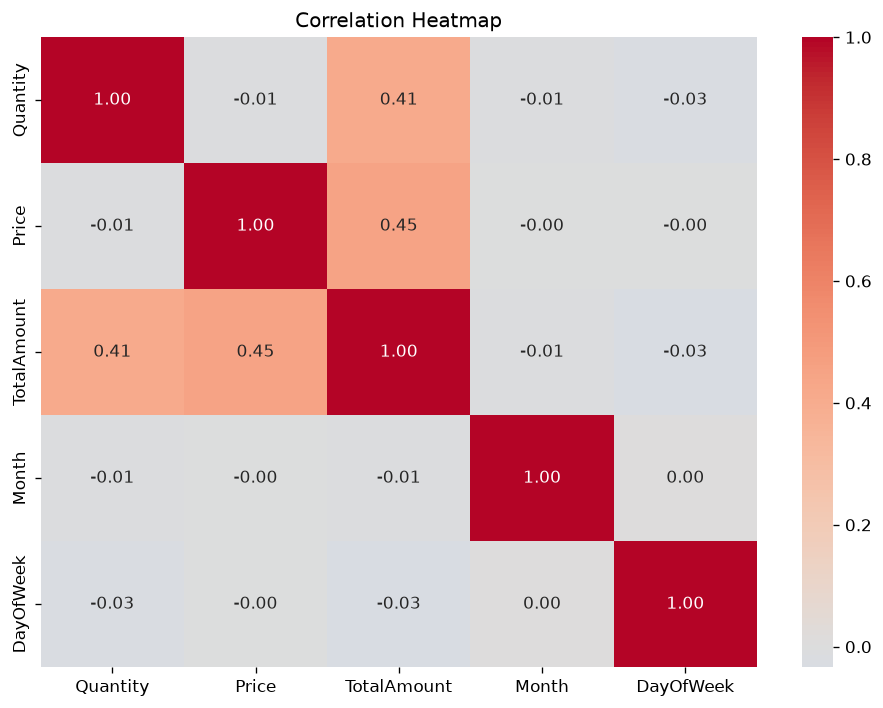

            Quantity          Price    TotalAmount          Month  \
count  400916.000000  400916.000000  400916.000000  400916.000000   
mean       13.767418       3.305826      21.945330       7.398166   
std        97.638385      35.047719      77.758075       3.472188   
min         1.000000       0.001000       0.001000       1.000000   
25%         2.000000       1.250000       5.000000       4.000000   
50%         5.000000       1.950000      12.500000       8.000000   
75%        12.000000       3.750000      19.500000      11.000000   
max     19152.000000   10953.500000   15818.400000      12.000000   

           DayOfWeek  
count  400916.000000  
mean        2.681420  
std         1.973988  
min         0.000000  
25%         1.000000  
50%         3.000000  
75%         4.000000  
max         6.000000  


In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

numeric_df = df[['Quantity', 'Price', 'TotalAmount', 'Month', 'DayOfWeek']].dropna()
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print(df[['Quantity', 'Price', 'TotalAmount', 'Month', 'DayOfWeek']].describe())

In [14]:
# %%[markdown]
# ## Top Products by Revenue

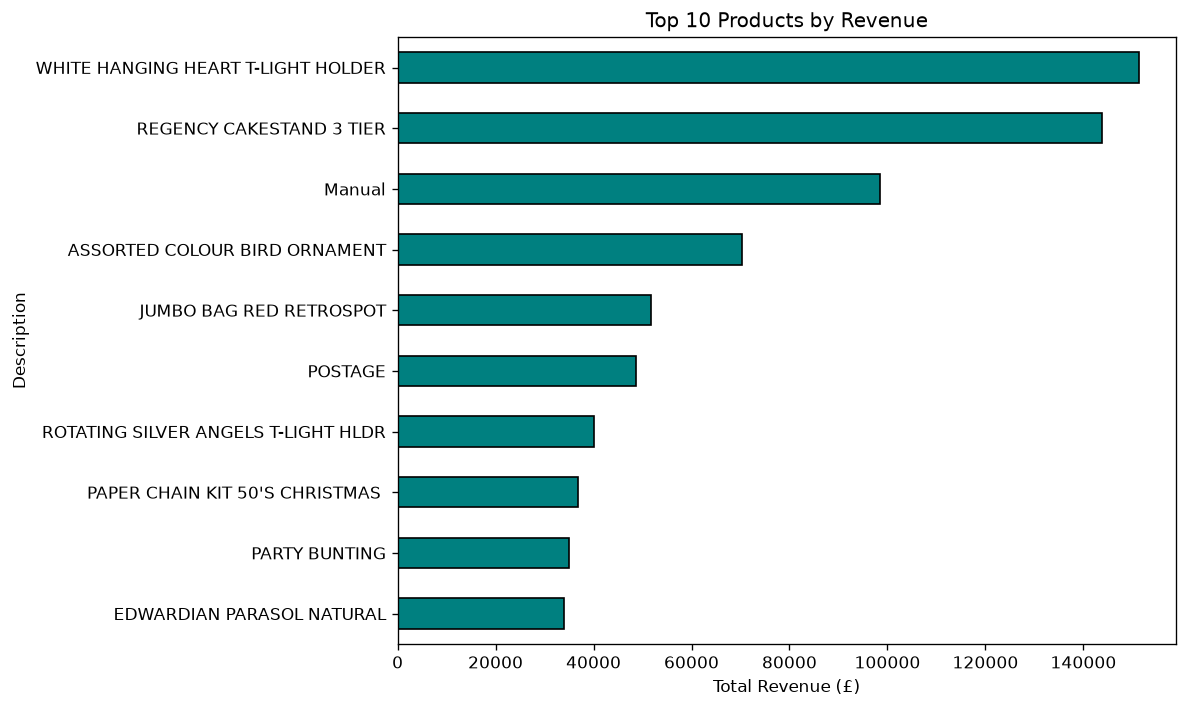

In [15]:
top_products = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/top_products.png', bbox_inches='tight')
plt.show()

In [16]:
# %%[markdown]
# ## Revenue by Country

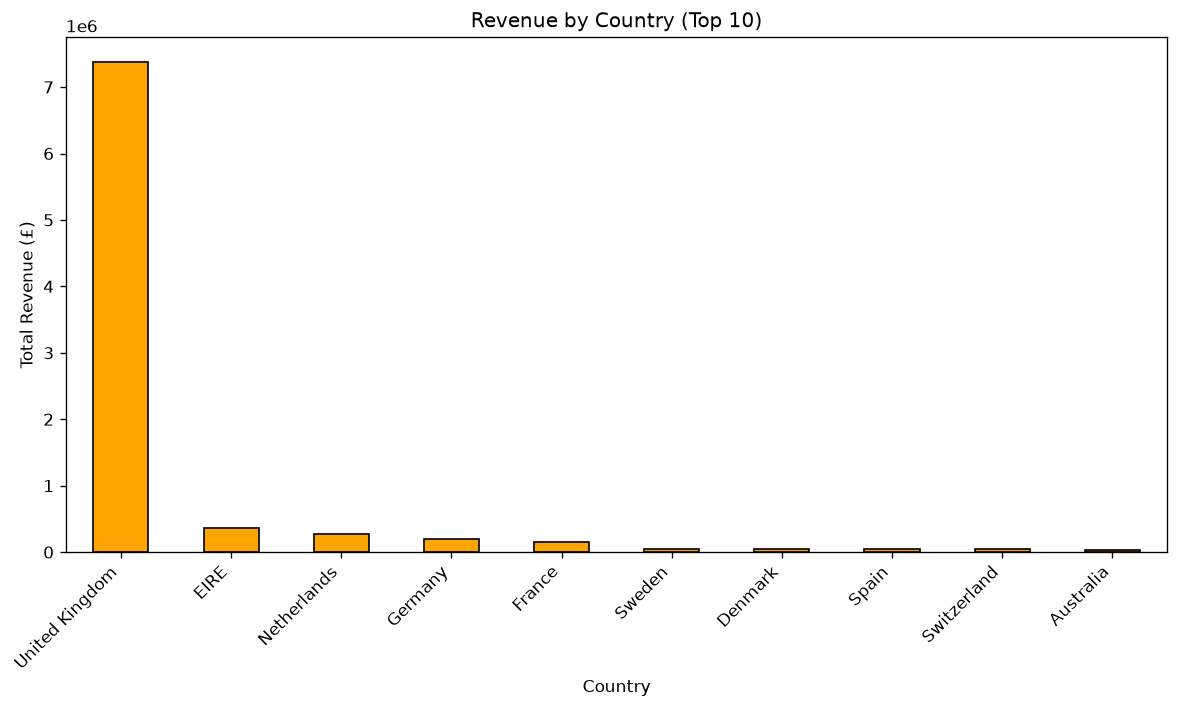

Total revenue: £8,798,233.74
Avg order value: £21.95
Total transactions: 400,916


In [17]:
top_countries = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Revenue by Country (Top 10)')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/revenue_by_country.png', bbox_inches='tight')
plt.show()

print(f"Total revenue: £{df['TotalAmount'].sum():,.2f}")
print(f"Avg order value: £{df['TotalAmount'].mean():.2f}")
print(f"Total transactions: {len(df):,}")